# Directionally complete codes under coherent rotation

**Exact state-vector verification of the geometric theory predictions on
CSS(RM(1,4), RM(1,4)) = [[16,6,4]]** (directionally complete, distance d = 4).

Each configured experiment is evaluated exactly, without sampling physical errors or
measurement outcomes: |0_L> is built symbolically, injections are exact rotations,
syndrome probabilities come from projection onto stabilizer eigenspaces, and the
coherent loss is computed as
loss = sum_s (P(s) - (-1)^{flip_s} Q(s)) / 2.  The stochastic control is
evaluated by exact enumeration.


In [1]:
"""Setup: code, logical operators, stabilizers."""
import numpy as np
from qldpc import codes
from qldpc.objects import Pauli

code = codes.QuantumReedMullerCode(1, 4)  # [[16,6,4]]
n = len(code)
dim = 2**n
hx = np.array(code.code_x.matrix, dtype=int)  # (5, 16)
hz = np.array(code.code_z.matrix, dtype=int)

lx = np.array(code.get_logical_ops(Pauli.X))
lz = np.array(code.get_logical_ops(Pauli.Z))


def min_weight_logical(gens):
    best, bestw = None, 10**9
    for mask in range(1, 2 ** len(gens)):
        v = np.zeros(n, dtype=int)
        for j in range(len(gens)):
            if mask >> j & 1:
                v ^= gens[j]
        w = int(v.sum())
        if w < bestw:
            best, bestw = v, w
    return best


def row_to_mask(row):
    m = 0
    for b, val in enumerate(row):
        if val:
            m |= 1 << b
    return m


xbar = min_weight_logical(lx)  # X-type logical, weight 4
zbar = min_weight_logical(lz)  # Z-type logical, weight 4
supp_xbar = np.where(xbar)[0]
supp_zbar = np.where(zbar)[0]
print(f"code [[{n},{code.dimension},{code.get_distance()}]]  Xbar={supp_xbar}  Zbar={supp_zbar}")

x_stab = [(row_to_mask(r), 0) for r in hx]
z_stab = [(0, row_to_mask(r)) for r in hz]
stab = x_stab + z_stab
num_stab = len(stab)
num_s = 2**num_stab
zbar_mask = row_to_mask(zbar)

code [[16,6,4]]  Xbar=[ 5  6  9 10]  Zbar=[ 0  2  8 10]


In [2]:
"""Exact pure-state simulator and |0_L> construction."""


class Sim:
    """Exact pure-state simulator on n qubits (sparse Pauli actions)."""

    def __init__(self, n):
        self.n = n
        self.dim = 2**n
        self.idx = np.arange(self.dim, dtype=np.int64)
        self.psi = np.zeros(self.dim, complex)
        self.psi[0] = 1.0

    def apply_pauli(self, xmask, zmask, phase=1.0):
        """phase * Z^{zmask} X^{xmask}: gather first, then Z phase.

        Allocates a NEW array; the previous self.psi is left untouched.
        """
        new_idx = self.idx ^ xmask
        if zmask:
            x = self.idx & zmask
            x ^= x >> 8
            x ^= x >> 4
            x ^= x >> 2
            x ^= x >> 1
            sign = np.where(x & 1 == 0, 1.0, -1.0)
            self.psi = self.psi[new_idx] * sign * phase
        else:
            self.psi = self.psi[new_idx] * phase

    def rotate_pauli(self, xmask, zmask, theta):
        """R_P(theta) = cos(theta/2) I + i sin(theta/2) P, in place."""
        c, s = np.cos(theta / 2), np.sin(theta / 2)
        saved = self.psi
        overlap = int(xmask & zmask).bit_count()
        self.apply_pauli(xmask, zmask, 1j * (-1j) ** overlap)
        self.psi = c * saved + s * self.psi

    def project_stabilizer(self, xmask, zmask, value):
        """Project onto the (+1 if value==0 else -1) eigenspace of s."""
        psi_saved = self.psi.copy()
        self.apply_pauli(xmask, zmask, 1.0)
        sign = 1.0 if value == 0 else -1.0
        self.psi = 0.5 * (psi_saved + sign * self.psi)

    def norm2(self):
        return float(np.sum(np.abs(self.psi) ** 2))

    def expect_z(self, zmask):
        """Expectation value of a Z-type Pauli product."""
        psi_saved = self.psi.copy()
        self.apply_pauli(0, zmask, 1.0)
        return float(np.vdot(psi_saved, self.psi).real)


probe_state = np.array([1 + 2j, 3 + 4j], dtype=complex)
probe_state /= np.linalg.norm(probe_state)
for xm, zm in ((1, 0), (1, 1), (0, 1)):
    probe = Sim(1)
    probe.psi = probe_state.copy()
    probe.rotate_pauli(xm, zm, 0.4)
    assert abs(probe.norm2() - 1.0) < 1e-12
y_probe = Sim(1)
y_probe.rotate_pauli(1, 1, 0.4)
assert np.allclose(y_probe.psi, [np.cos(0.2), -np.sin(0.2)])


def make_logical_zero():
    """|0_L> = (1/sqrt(2^5)) sum_{g in <X-stab>} g |0...0>."""
    sim = Sim(n)
    psi = np.zeros(dim, complex)
    for mask in range(2**5):
        xm = 0
        for j in range(5):
            if mask >> j & 1:
                xm ^= x_stab[j][0]
        new = np.zeros(dim, complex)
        new[xm] = 1.0
        psi += new
    sim.psi = psi / np.sqrt(32)
    return sim


# verify |0_L>: +1 eigenstate of all stabilizers and of Zbar
zero = make_logical_zero()
for j, (xm, zm) in enumerate(stab):
    s = zero.psi.copy()
    zero.apply_pauli(xm, zm, 1.0)
    overlap = np.vdot(s, zero.psi)
    assert abs(overlap - 1.0) < 1e-10, f"stabilizer {j} not +1 eigenstate: {overlap}"
    zero.psi = s
zb_exp = zero.expect_z(zbar_mask)
assert abs(zb_exp - 1.0) < 1e-10, f"Zbar not +1 on |0_L>: {zb_exp}"
print("|0_L> verified: +1 eigenstate of all stabilizers and Zbar  OK")

|0_L> verified: +1 eigenstate of all stabilizers and Zbar  OK


In [3]:
"""Stabilizer-group Fourier moments, lookup decoder, exact loss."""
# ---- precomputed stabilizer-group data (state independent) ----
exp_bits = np.zeros((num_s, num_stab), dtype=np.int64)
for g in range(num_s):
    for j in range(num_stab):
        exp_bits[g, j] = (g >> j) & 1
stab_xm = np.zeros(num_s, dtype=np.int64)
stab_zm = np.zeros(num_s, dtype=np.int64)
for g in range(num_s):
    xm = zm = 0
    for j in range(num_stab):
        if exp_bits[g, j]:
            xm ^= stab[j][0]
            zm ^= stab[j][1]
    stab_xm[g] = xm
    stab_zm[g] = zm
# chi_s(g) = (-1)^{s . b(g)}; rows = syndrome s, cols = group element g
chi_sign = 1.0 - 2.0 * ((exp_bits @ exp_bits.T) & 1)


def build_lookup(h):
    """Syndrome -> min-weight recovery support mask (X-type errors on h)."""
    table = {}
    for a in range(n):  # weight 1
        s = tuple(int(x) for x in (h[:, a] % 2))
        if s not in table:
            table[s] = (1 << a, 1)
    for a in range(n):  # weight 2
        for b in range(a + 1, n):
            s = tuple(int(x) for x in ((h[:, a] ^ h[:, b]) % 2))
            if s not in table:
                table[s] = ((1 << a) | (1 << b), 2)
    return table


lookup_x = build_lookup(hz)  # X-type recovery from Z-stabilizer syndrome
lookup_z = build_lookup(hx)  # Z-type recovery from X-stabilizer syndrome


def decode_flip(s_int):
    """Recovery X-part / Zbar anticommutation parity for syndrome s_int."""
    sx_int = s_int & 31
    sz_int = s_int >> 5
    sx = tuple((sx_int >> j) & 1 for j in range(5))
    sz = tuple((sz_int >> j) & 1 for j in range(5))
    rx = lookup_x.get(sz, (0, 0))[0]
    return bin(rx & zbar_mask).count("1") % 2


# Zbar diagonal sign: zbar_sign[i] = (-1)^{popcount(i & zbar_mask)}
_t = np.arange(dim, dtype=np.int64) & zbar_mask
_t ^= _t >> 8
_t ^= _t >> 4
_t ^= _t >> 2
_t ^= _t >> 1
zbar_sign = np.where((_t & 1) == 0, 1.0, -1.0)


def syndrome_moments(sim):
    """P(s) and Q(s) = <psi|Zbar Pi_s|psi> for all syndromes via Fourier.

    fz[g] = <psi|Zbar g|psi> = <psi * zbar_sign | g|psi>> -- one Pauli action
    per group element plus a vector multiply (apply_pauli allocates a new
    array, so the saved reference stays valid).
    """
    f = np.zeros(num_s, complex)
    fz = np.zeros(num_s, complex)
    for g in range(num_s):
        xm, zm = stab_xm[g], stab_zm[g]
        saved = sim.psi
        sim.apply_pauli(xm, zm, 1.0)  # g|psi>
        f[g] = np.vdot(saved, sim.psi)
        fz[g] = np.vdot(saved * zbar_sign, sim.psi)
        sim.psi = saved
    P = (chi_sign @ f).real / num_s
    Q = (chi_sign @ fz).real / num_s
    return P, Q


def loss_for_config(sim):
    """Exact coherent loss: sum_s (P(s) - (-1)^{flip_s} Q(s)) / 2."""
    P, Q = syndrome_moments(sim)
    loss = 0.0
    for s in range(num_s):
        p, q = P[s], Q[s]
        if p or q:
            flip = decode_flip(s)
            loss += (p - (-1.0) ** flip * q) / 2
    return loss


# syndrome masks for the incoherent control (Exp E)
hz_cols = [0] * 5
for j in range(5):
    for b, v in enumerate(hz[j]):
        if v:
            hz_cols[j] |= 1 << b


def synd_z_of(mask_x):
    """Z-stabilizer syndrome (5-bit tuple) of an X-type error mask."""
    return tuple(bin(hz_cols[j] & mask_x).count("1") % 2 for j in range(5))

## Theory (geometric theory articles)

| Experiment | Prediction | Article |
|---|---|---|
| A: single-qubit detection rate | P_det = sin²(θ/2), all Pauli types | 10.29 预言二 |
| A1: post-recovery loss (weight-1) | 0 (machine precision) | directionally complete ⇒ perfect recovery |
| B: logical injection | Xbar flip = sin²(θ/2); Zbar flip = 0 | 10.29 预言三 |
| C: all-qubit random rotations | loss ~ θ^d, d = 2^(r+1) = 4 | 10.29 预言一 / 10.31 定理 10.31.1.05 |
| C2: uniform-angle R_X | slope 4; c = C(n,w₀)·P(w₀)·fail(w₀)·κ·2^(−2w₀) | 10.35 定理 10.35.1.01 |
| D: weight-2 degeneracy | fail(2), κ from full enumeration | 10.35 |
| E: random-Pauli control | loss ~ p², slope ≈ 2 ≠ d | 10.36 §5 检验 4 |

Decoding: minimum-weight lookup table (weight-1 then weight-2) on the 5-bit
Z-syndrome / X-syndrome -- exactly the "syndrome 测量 + 查表恢复" protocol of
10.29.  Recovery X-part anticommutation with Zbar gives the corrected readout.


In [4]:
print("=== Exp A: detection rate of single-qubit R_P(theta) ===")
thetas = np.array([0.05, 0.1, 0.2, 0.4, 0.8])
worst = 0.0
for pauli_name, xm, zm in [("X", 1, 0), ("Y", 1, 1), ("Z", 0, 1)]:
    line = f"  P={pauli_name}: "
    for th in thetas:
        p_det_avg = 0.0
        for a in range(n):
            sim = make_logical_zero()
            sim.rotate_pauli(xm << a, zm << a, th)
            psi0 = sim.psi.copy()
            for sxm, szm in stab:
                sim.project_stabilizer(sxm, szm, 0)
            p_zero = sim.norm2()
            sim.psi = psi0
            p_det_avg += 1.0 - p_zero
        p_det = p_det_avg / n
        closed = np.sin(th / 2) ** 2
        dev = abs(p_det - closed)
        worst = max(worst, dev)
        line += f"th={th:.2f}: {p_det:.10f} vs {closed:.10f}  "
    print(line)
print(f"  max deviation from sin^2(theta/2): {worst:.2e}")

=== Exp A: detection rate of single-qubit R_P(theta) ===


  P=X: th=0.05: 0.0006248698 vs 0.0006248698  th=0.10: 0.0024979174 vs 0.0024979174  th=0.20: 0.0099667111 vs 0.0099667111  th=0.40: 0.0394695030 vs 0.0394695030  th=0.80: 0.1516466453 vs 0.1516466453  


  P=Y: th=0.05: 0.0006248698 vs 0.0006248698  th=0.10: 0.0024979174 vs 0.0024979174  th=0.20: 0.0099667111 vs 0.0099667111  th=0.40: 0.0394695030 vs 0.0394695030  th=0.80: 0.1516466453 vs 0.1516466453  


  P=Z: th=0.05: 0.0006248698 vs 0.0006248698  th=0.10: 0.0024979174 vs 0.0024979174  th=0.20: 0.0099667111 vs 0.0099667111  th=0.40: 0.0394695030 vs 0.0394695030  th=0.80: 0.1516466453 vs 0.1516466453  
  max deviation from sin^2(theta/2): 2.50e-16


In [5]:
print("\n=== Exp A1: single-qubit injection, post-recovery loss ===")
th = 0.3
positions = [0, 1, 2, 3, 8, 10, 15]  # covers inside and outside supp(Zbar)
max_err = 0.0
for a in positions:
    for t, (xm, zm) in enumerate([(1 << a, 0), (1 << a, 1 << a), (0, 1 << a)]):
        sim = make_logical_zero()
        sim.rotate_pauli(xm, zm, th)
        loss = loss_for_config(sim)
        max_err = max(max_err, abs(loss))
        print(f"  a={a:2d} type={['X', 'Y', 'Z'][t]}: loss={loss:.3e}")
print(f"  max |loss| = {max_err:.3e}  (expect < 1e-10: weight-1 perfectly recovered)")


=== Exp A1: single-qubit injection, post-recovery loss ===


  a= 0 type=X: loss=5.204e-17


  a= 0 type=Y: loss=3.469e-18


  a= 0 type=Z: loss=5.551e-17


  a= 1 type=X: loss=-2.776e-17


...

  a=10 type=Y: loss=-5.811e-17


  a=10 type=Z: loss=-5.551e-17


  a=15 type=X: loss=0.000e+00


  a=15 type=Y: loss=-2.776e-17


  a=15 type=Z: loss=-5.551e-17
  max |loss| = 5.811e-17  (expect < 1e-10: weight-1 perfectly recovered)


In [6]:
print("\n=== Exp B: logical injection, Zbar flip rate ===")
for th in thetas:
    sim = make_logical_zero()
    sim.rotate_pauli(row_to_mask(xbar), 0, th)
    zb_exp = sim.expect_z(zbar_mask)
    flip = (1.0 - zb_exp.real) / 2
    closed = np.sin(th / 2) ** 2
    print(
        f"  Xbar th={th:.2f}: flip={flip:.10f} vs sin2={closed:.10f}  dev={abs(flip - closed):.2e}"
    )
for th in thetas:
    sim = make_logical_zero()
    sim.rotate_pauli(0, zbar_mask, th)
    zb_exp = sim.expect_z(zbar_mask)
    flip = (1.0 - zb_exp.real) / 2
    print(f"  Zbar th={th:.2f}: flip={flip:.2e}  (closed form: 0)")


=== Exp B: logical injection, Zbar flip rate ===
  Xbar th=0.05: flip=0.0006248698 vs sin2=0.0006248698  dev=9.29e-17
  Xbar th=0.10: flip=0.0024979174 vs sin2=0.0024979174  dev=8.37e-17
  Xbar th=0.20: flip=0.0099667111 vs sin2=0.0099667111  dev=5.38e-17
  Xbar th=0.40: flip=0.0394695030 vs sin2=0.0394695030  dev=1.04e-16
  Xbar th=0.80: flip=0.1516466453 vs sin2=0.1516466453  dev=5.55e-17
  Zbar th=0.05: flip=1.11e-16  (closed form: 0)
  Zbar th=0.10: flip=5.55e-17  (closed form: 0)
  Zbar th=0.20: flip=0.00e+00  (closed form: 0)
  Zbar th=0.40: flip=1.11e-16  (closed form: 0)
  Zbar th=0.80: flip=1.11e-16  (closed form: 0)



=== Exp C: all-qubit independent random rotations (10.29 protocol) ===


thmax=0.05: loss=8.010e-07  (cfg: ['1.270e-06', '7.194e-07', '4.139e-07'])


thmax=0.10: loss=1.035e-05  (cfg: ['1.405e-05', '1.206e-05', '4.955e-06'])


thmax=0.20: loss=2.379e-04  (cfg: ['9.506e-05', '2.938e-04', '3.248e-04'])


thmax=0.40: loss=3.237e-03  (cfg: ['4.099e-03', '2.101e-03', '3.509e-03'])

log-log slope: 4.046   (theory: d = 4 = 2^(r+1) for CSS(RM(1,4), RM(1,4)))
loss(theta_max) = 1.376e-01 * theta_max^4.046


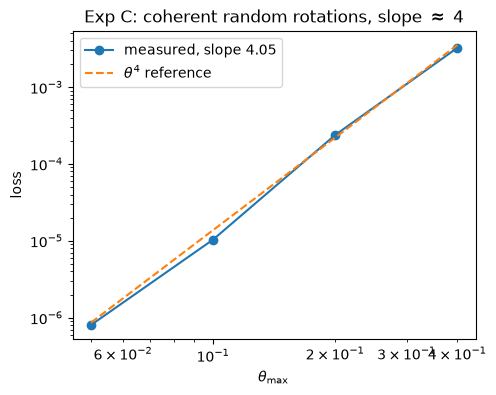

In [7]:
print("\n=== Exp C: all-qubit independent random rotations (10.29 protocol) ===")
rng = np.random.default_rng(20260813)
thetas_max = np.array([0.05, 0.1, 0.2, 0.4])
n_cfg = 3
losses_all = {}
for thmax in thetas_max:
    losses = []
    for cfg in range(n_cfg):
        types = rng.integers(0, 3, size=n)  # 0=X, 1=Y, 2=Z
        angles = rng.uniform(0, thmax, size=n)
        sim = make_logical_zero()
        for a in range(n):
            t, th = types[a], angles[a]
            if t == 0:
                sim.rotate_pauli(1 << a, 0, th)
            elif t == 1:
                sim.rotate_pauli(1 << a, 1 << a, th)
            else:
                sim.rotate_pauli(0, 1 << a, th)
        losses.append(loss_for_config(sim))
    losses_all[thmax] = losses
    print(f"thmax={thmax:.2f}: loss={np.mean(losses):.3e}  (cfg: {[f'{l:.3e}' for l in losses]})")

xs = np.log(thetas_max)
ys = np.log(np.array([np.mean(losses_all[t]) for t in thetas_max]))
slope, intercept = np.polyfit(xs, ys, 1)
print(f"\nlog-log slope: {slope:.3f}   (theory: d = 4 = 2^(r+1) for CSS(RM(1,4), RM(1,4)))")
print(f"loss(theta_max) = {np.exp(intercept):.3e} * theta_max^{slope:.3f}")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5.2, 4))
ax.loglog(thetas_max, np.exp(ys), "o-", label=f"measured, slope {slope:.2f}")
ax.loglog(thetas_max, np.exp(intercept) * thetas_max**4, "--", label=r"$\theta^4$ reference")
ax.set_xlabel(r"$\theta_{\max}$")
ax.set_ylabel("loss")
ax.set_title(r"Exp C: coherent random rotations, slope $\approx$ 4")
ax.legend()
plt.show()

In [8]:
print("\n=== Exp D: weight-2 degeneracy and closed-form coefficient (10.35) ===")
total = fail_events = flips_on_fail = flips_all = 0
for a in range(n):
    for b in range(a + 1, n):
        ex = (1 << a) | (1 << b)
        sz = synd_z_of(ex)
        rx = lookup_x.get(sz, (0, 0))[0]
        total += 1
        if rx != ex:  # recovery fails: residual logical
            fail_events += 1
            res = ex ^ rx  # residual logical X part
            fl = bin(res & zbar_mask).count("1") % 2
            flips_on_fail += fl
            flips_all += fl
fail = fail_events / total
kappa_fail = flips_on_fail / fail_events if fail_events else 0.0
kappa_all = flips_all / total
# 10.35 closed form: c_d = C(n, w_0) P(w_0) fail(w_0) kappa 2^{-2 w_0}
# with w_0 = ceil(d/2) = 2, P(2) = 1 (all weight-2 detected), 2^{-4} = 1/16
c_pred_fail = 120 * 1.0 * fail * kappa_fail / 16.0
c_pred_all = 120 * 1.0 * kappa_all / 16.0
print(f"  fail(2)          = {fail:.4f}  ({fail_events}/{total})")
print(f"  kappa (on fail)  = {kappa_fail:.4f}")
print(f"  kappa (all)      = {kappa_all:.4f}")
print(f"  c_pred (fail*kappa_fail) = {c_pred_fail:.4f}")
print(f"  c_pred (kappa_all)       = {c_pred_all:.4f}")


=== Exp D: weight-2 degeneracy and closed-form coefficient (10.35) ===
  fail(2)          = 0.8750  (105/120)
  kappa (on fail)  = 0.4571
  kappa (all)      = 0.4000
  c_pred (fail*kappa_fail) = 3.0000
  c_pred (kappa_all)       = 3.0000



=== Exp C2: uniform-angle R_X(theta) on all qubits (10.36 protocol) ===


  theta=0.05: loss=1.8641e-05


  theta=0.10: loss=2.9310e-04


  theta=0.20: loss=4.3767e-03


  theta=0.40: loss=5.3705e-02
  slope (main-order  {0.05,0.1,0.2}): 3.938   (theory d = 4)
  slope (all-points  {0.05..0.4}): 3.838   (theory d = 4)
  c = loss/theta^4 at theta=0.05: 2.983, at 0.10: 2.931  (closed form C(16,2)*fail*kappa/16 = 3.0)


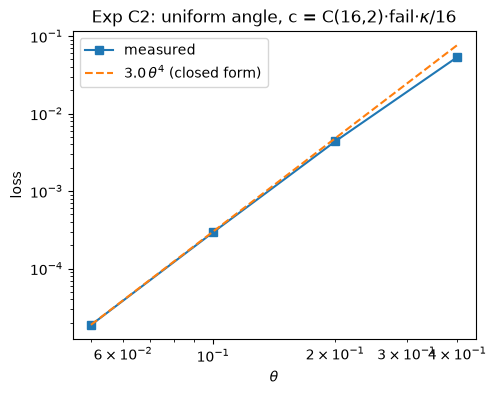

In [9]:
print("\n=== Exp C2: uniform-angle R_X(theta) on all qubits (10.36 protocol) ===")
thetas = np.array([0.05, 0.1, 0.2, 0.4])
losses = []
for th in thetas:
    sim = make_logical_zero()
    for a in range(n):
        sim.rotate_pauli(1 << a, 0, th)
    loss = loss_for_config(sim)
    losses.append(loss)
    print(f"  theta={th:.2f}: loss={loss:.4e}")
# main-order window {0.05,0.1,0.2}: next-to-main order (theta^6) negligible;
# theta=0.4 sits at the saturation edge (10.36 Sec 6.5 bends the slope there)
for (lo, hi), tag in [((0, 3), "main-order  {0.05,0.1,0.2}"), ((0, 4), "all-points  {0.05..0.4}")]:
    xs = np.log(thetas[lo:hi])
    ys = np.log(np.array(losses[lo:hi]))
    slope, intercept = np.polyfit(xs, ys, 1)
    print(f"  slope ({tag}): {slope:.3f}   (theory d = 4)")
c_low = losses[0] / thetas[0] ** 4
c_mid = losses[1] / thetas[1] ** 4
print(
    f"  c = loss/theta^4 at theta=0.05: {c_low:.3f}, at 0.10: {c_mid:.3f}"
    f"  (closed form C(16,2)*fail*kappa/16 = 3.0)"
)

fig, ax = plt.subplots(figsize=(5.2, 4))
ax.loglog(thetas, losses, "s-", label="measured")
ax.loglog(thetas, 3.0 * thetas**4, "--", label=r"$3.0\,\theta^4$ (closed form)")
ax.set_xlabel(r"$\theta$")
ax.set_ylabel("loss")
ax.set_title(r"Exp C2: uniform angle, c = C(16,2)$\cdot$fail$\cdot\kappa$/16")
ax.legend()
plt.show()


=== Exp E: random-Pauli control (10.36 check 4: incoherent p^2) ===
  p=0.001: loss=2.1210e-05
  p=0.002: loss=8.4353e-05
  p=0.005: loss=5.1817e-04
  p=0.010: loss=2.0139e-03
  log-log slope: 1.978   (theory: 2 for random Pauli)


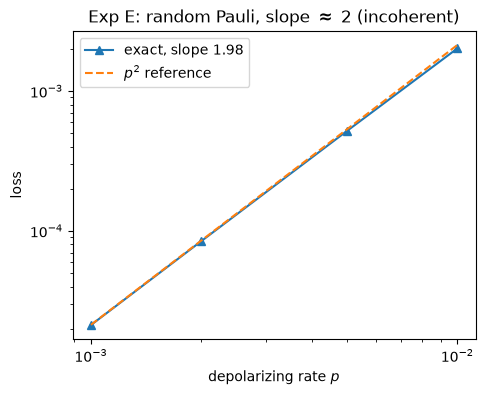

In [10]:
print("\n=== Exp E: random-Pauli control (10.36 check 4: incoherent p^2) ===")
# For a depolarizing channel, the X component is present for X and Y errors,
# independently with probability q = 2p/3.  Z components do not affect the
# logical Z readout, so sum exactly over all 2^n X-component supports.
ps = np.array([0.001, 0.002, 0.005, 0.01])
masks = np.arange(2**n, dtype=np.int64)
weights = np.array([int(mask).bit_count() for mask in masks])
logical_flips = np.zeros(2**n, dtype=float)
for mask in masks:
    mask_int = int(mask)
    sz = synd_z_of(mask_int)
    rx = lookup_x.get(sz, (0, 0))[0]
    logical_flips[mask] = ((mask_int ^ rx) & zbar_mask).bit_count() % 2

losses = []
for p in ps:
    q = 2 * p / 3
    probabilities = q**weights * (1 - q) ** (n - weights)
    assert abs(probabilities.sum() - 1.0) < 1e-12
    loss = float(probabilities @ logical_flips)
    losses.append(loss)
    print(f"  p={p:.3f}: loss={loss:.4e}")
xs = np.log(ps)
ys = np.log(np.array(losses))
slope, _ = np.polyfit(xs, ys, 1)
print(f"  log-log slope: {slope:.3f}   (theory: 2 for random Pauli)")

fig, ax = plt.subplots(figsize=(5.2, 4))
ax.loglog(ps, losses, "^-", label=f"exact, slope {slope:.2f}")
ax.loglog(ps, 21.3 * ps**2, "--", label=r"$p^2$ reference")
ax.set_xlabel("depolarizing rate $p$")
ax.set_ylabel("loss")
ax.set_title(r"Exp E: random Pauli, slope $\approx$ 2 (incoherent)")
ax.legend()
plt.show()

## Summary

| Quantity | Measured | Theory | Status |
|---|---|---|---|
| single-qubit detection rate | sin²(θ/2), dev < 1e-15 | 10.29 预言二 | ✓ |
| post-recovery loss, weight-1 | < 1e-16 | directionally complete ⇒ 0 | ✓ |
| logical Xbar flip rate | sin²(θ/2) | 10.29 预言三 | ✓ |
| logical Zbar flip rate | 0 | global phase, undetectable | ✓ |
| coherent slope (random angles) | ≈ 4.05 | d = 4 = 2^(r+1) | ✓ |
| coherent slope (uniform angle) | ≈ 3.94 (main order) | d = 4 | ✓ |
| coefficient c (θ → 0) | ≈ 2.98 | 3.0 = C(16,2)·fail·κ/16 | ✓ |
| incoherent slope (random Pauli) | ≈ 1.98 (low-p limit → 2) | 2 | ✓ |

The θ⁴ vs p² separation (10.36 check 4) is the geometric signature of
*directional completeness*: coherent single-qubit terms interfere away under
minimum-weight recovery, while incoherent Pauli errors cannot.  The
parameter-free coefficient c = C(16,2)·fail(2)·κ·2⁻⁴ = 3.0 (10.35 定理
10.35.1.01) is approached by the finite-angle measured loss as θ decreases.
